In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import HestonTrainer
from neural_network.config import HestonParams, HestonParamsMulti, ModelConfig
from neural_network.payoff import Put, PutProductMultipleAssets

from heston.tree import HestonTreeFast

/Users/jameswu/Documents/Imperial/Year 4/M4R/M4R_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
exercise_type = "american"

n_assets = 2

S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma_bar = 0.3  # Volatility of variance
v0 = 0.04    # Initial variance

sigma = np.array([0.2, 0.25])  # Volatility of each asset

# Correlation matrix
rho_asset = 0 # Correlation between assets
Sigma = np.full((n_assets, n_assets), rho_asset)
np.fill_diagonal(Sigma, 1.0)

rho_cross = [0.3, 0.4]  # Correlation between stock price and variance for each asset

S_min = 0.0
V_min = 0.05
S_max = 3 * S0
V_max = 5 * v0

params = HestonParamsMulti(
    n_assets=n_assets, S0=S0, v0=v0, r=r,
    kappa=kappa, theta=theta, sigma_bar=sigma_bar, sigma=sigma, Sigma=Sigma, rho=rho_cross, K=K, T=T,
    S_min=S_min, S_max=S_max, V_min=V_min, V_max=V_max
)


In [3]:
model_config = ModelConfig(
    input_size=n_assets + 2, # Stock prices + variance + time
    hidden_sizes=[128, 256, 256, 128],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-3,
    dropout=0.1
)

# loss_weights = {
#     'pde': 20,
#     'payoff': 1,
#     'S_min': 1,
#     'S_max': 10,
#     'V_min': 0,
#     'V_max': 1,
# }

payoff = PutProductMultipleAssets()

In [4]:
heston_trainer = HestonTrainer(model_config, params, payoff, exercise_type, seed=14)

optimal_weights = heston_trainer.optimise_loss_weights(
    batch_size=1000, n_trials=30, epochs_per_trial=300
)
heston_trainer.set_loss_weights(optimal_weights)

[I 2026-03-04 16:57:37,835] A new study created in memory with name: no-name-cecaf372-9d8f-47cd-a560-97bd1a698c78
Best trial: 0. Best value: 0.0244026:   3%|▎         | 1/30 [00:24<11:51, 24.52s/it]

[I 2026-03-04 16:58:02,360] Trial 0 finished with value: 0.024402621258050202 and parameters: {'pde': 3.609277034038328, 'payoff': 14.49558889487763, 'S_min': 0.1324023556398819, 'S_max': 0.008890253854487986, 'V_min': 0.002305126090860146, 'V_max': 0.0036150427600458285}. Best is trial 0 with value: 0.024402621258050202.


Best trial: 1. Best value: 0.020017:   7%|▋         | 2/30 [00:47<10:58, 23.53s/it] 

[I 2026-03-04 16:58:25,195] Trial 1 finished with value: 0.020016979156062008 and parameters: {'pde': 0.47582983682095, 'payoff': 25.40764125291731, 'S_min': 0.002772795578733772, 'S_max': 0.0013425759992491627, 'V_min': 0.15197810108867696, 'V_max': 0.026000361730573456}. Best is trial 1 with value: 0.020016979156062008.


Best trial: 2. Best value: 0.00301241:  10%|█         | 3/30 [01:10<10:24, 23.13s/it]

...

[I 2026-03-04 17:05:40,636] Trial 27 pruned. 


Best trial: 22. Best value: 0.000496032:  97%|█████████▋| 29/30 [08:11<00:15, 15.38s/it]

[I 2026-03-04 17:05:48,846] Trial 28 pruned. 


Best trial: 22. Best value: 0.000496032: 100%|██████████| 30/30 [08:19<00:00, 16.64s/it]

[I 2026-03-04 17:05:56,938] Trial 29 pruned. 


In [5]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-8)

Iteration 0, Loss: 0.05347708612680435
Iteration 100, Loss: 0.00043704884592443705
Iteration 200, Loss: 0.00016005586076062173
Iteration 300, Loss: 0.0001006420498015359
Iteration 400, Loss: 9.189314732793719e-05
Iteration 500, Loss: 7.954660395625979e-05
Iteration 600, Loss: 7.377837755484506e-05
Iteration 700, Loss: 5.970048005110584e-05
Iteration 800, Loss: 6.227583071449772e-05
Iteration 900, Loss: 5.783416418125853e-05
Iteration 1000, Loss: 6.105656211730093e-05
Iteration 1100, Loss: 5.502232670551166e-05
Iteration 1200, Loss: 5.195167614147067e-05
Iteration 1300, Loss: 4.9845217290567234e-05
Iteration 1400, Loss: 4.817270382773131e-05
Iteration 1500, Loss: 4.801875547855161e-05
Iteration 1600, Loss: 4.820496906177141e-05
Iteration 1700, Loss: 4.8342470108764246e-05
Iteration 1800, Loss: 4.984846600564197e-05
Iteration 1900, Loss: 4.541866292129271e-05
Iteration 2000, Loss: 4.8690784751670435e-05
Early stopping at epoch 2024


In [ ]:
print(optimal_weights)
optimal_weights = {'pde': 0.021319245658608005, 'payoff': 0.010025881387829113, 'S_min': 0.007314912625034052, 'S_max': 1.0132688177164628, 'V_min': 3.6463396769735574, 'V_max': 0.0024456596683774543}
# heston_trainer.plot_losses_detailed(start_epoch=100)

{'pde': 0.021319245658608005, 'payoff': 0.010025881387829113, 'S_min': 0.007314912625034052, 'S_max': 1.0132688177164628, 'V_min': 3.6463396769735574, 'V_max': 0.0024456596683774543}


In [7]:
S1 = np.linspace(S_min, S_max, 100)
S2 = np.linspace(S_min, S_max, 100)

V = v0

# Create a grid of stock prices
S1_grid, S2_grid = np.meshgrid(S1, S2)
S_grid = np.stack([S1_grid, S2_grid], axis=-1).reshape(-1, 2)
t = np.zeros((S_grid.shape[0], 1))  # Time to maturity is 0 at maturity
with torch.no_grad():
    model = heston_trainer.model
    model.eval()
    S_tensor = torch.tensor(S_grid, dtype=torch.float32)
    t_tensor = torch.tensor(t, dtype=torch.float32)
    V_tensor = torch.tensor([[V]], dtype=torch.float32).repeat(S_tensor.shape[0], 1)
    payoffs = model(t_tensor, S_tensor, V_tensor).numpy().reshape(100, 100)

## Reduce to 1D case

In [8]:
A = np.sum(np.square(sigma))
b = Sigma.T @ sigma
B = np.sum(np.square(b))

r_1d = n_assets * r + 0.5 * v0 * (B - A)
kappa_1d = kappa
theta_1d = B * theta
sigma_bar_1d = np.sqrt(B) * sigma_bar


In [9]:
n = 100
mv = 3 * n
mz = 6 * n
V0_min = v0 * 0.25
V0_max = v0 * 3
S0_min = S0 * 0.01
S0_max = S0 * 3

rho = np.mean(rho_cross)

heston_tree = HestonTreeFast(n, mz, mv, K, T, r_1d, kappa_1d, theta_1d, sigma_bar_1d, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min**2, S0_max=S0_max**2,
                       option_type="put", exercise_type="american")

In [10]:
V = v0
S1 = np.linspace(S0_min, S0_max, 100)
S2 = np.linspace(S0_min, S0_max, 100)

# Create a grid of stock prices
S1_grid, S2_grid = np.meshgrid(S1, S2)
S_grid = np.stack([S1_grid, S2_grid], axis=-1).reshape(-1, 2)

S_prod = S_grid[:, 0] * S_grid[:, 1]
t = np.zeros((S_prod.shape[0], 1))  # Time to maturity is 0 at maturity
payoffs_ht = heston_tree.price(V, S_prod, 0).reshape(100, 100)

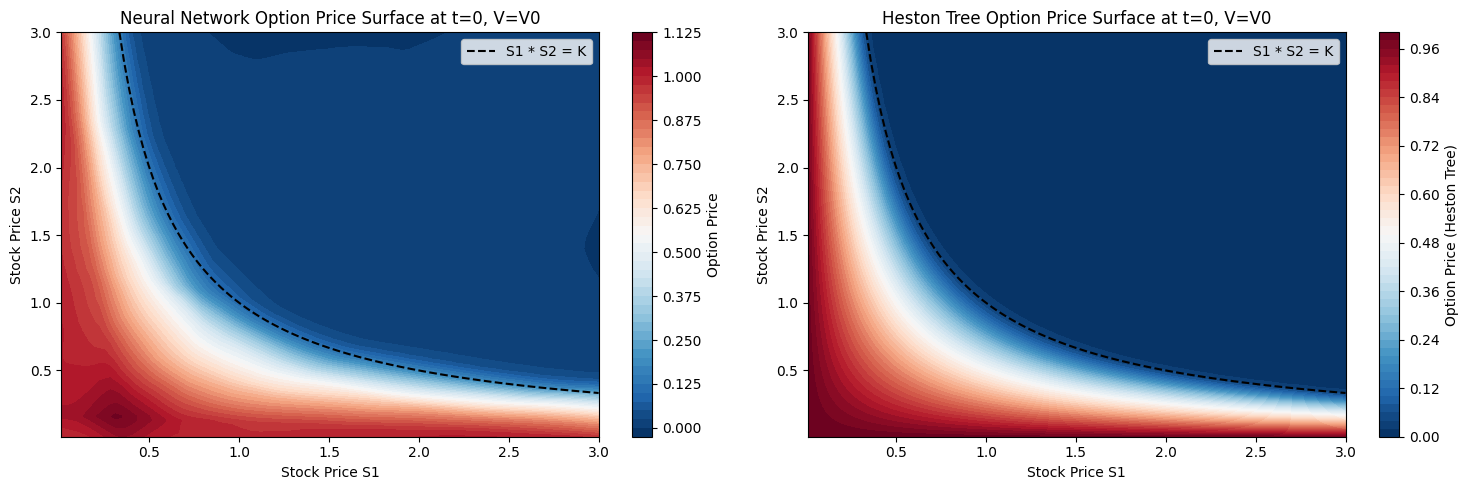

In [11]:
# Plotting the results
Xs = np.linspace(K / S_max, S_max, 100)
Ys = K / Xs

plt.figure(figsize=(15, 5))

# Plot the neural network price surface
plt.subplot(1, 2, 1)
plt.contourf(S1_grid, S2_grid, payoffs, levels=50, cmap='RdBu_r')
plt.colorbar(label='Option Price')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Neural Network Option Price Surface at t=0, V=V0')
plt.legend()

plt.subplot(1, 2, 2)
plt.contourf(S1_grid, S2_grid, payoffs_ht, levels=50, cmap='RdBu_r')
plt.colorbar(label='Option Price (Heston Tree)')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Heston Tree Option Price Surface at t=0, V=V0')
plt.legend()

plt.tight_layout()
plt.show()

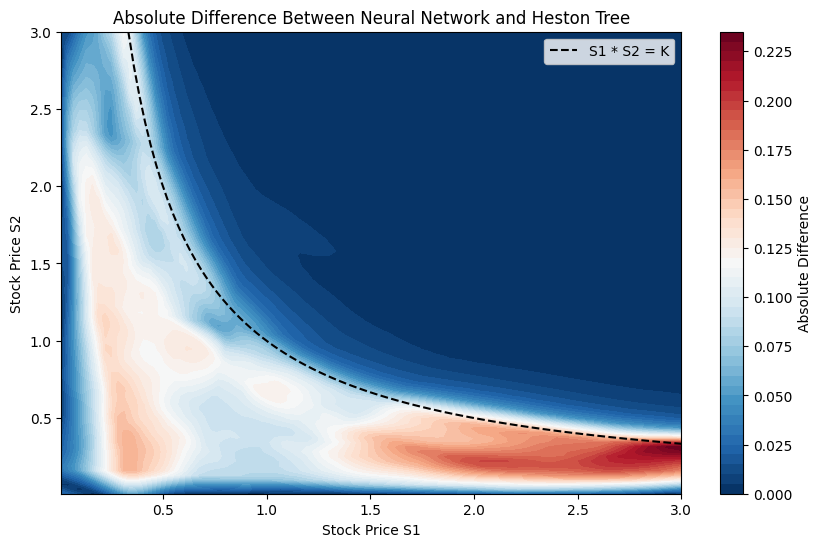

In [12]:
diff = np.abs(payoffs - payoffs_ht)

plt.figure(figsize=(10, 6))
plt.contourf(S1_grid, S2_grid, diff, levels=50, cmap='RdBu_r')
plt.colorbar(label='Absolute Difference')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Absolute Difference Between Neural Network and Heston Tree')
plt.legend()
plt.show()

In [13]:
# Along strike price
resolution = 100
S1_vals = np.linspace(K / S_max, S_max, resolution)
S2_vals = K / S1_vals

ht_prices_strike = heston_trainer.predict(np.zeros((resolution, 1)), S1_vals, S2_vals, np.full((resolution, 1), v0)).detach().numpy().flatten()
tree_price_strike = heston_tree.price(v0, S1_vals * S2_vals, 0)

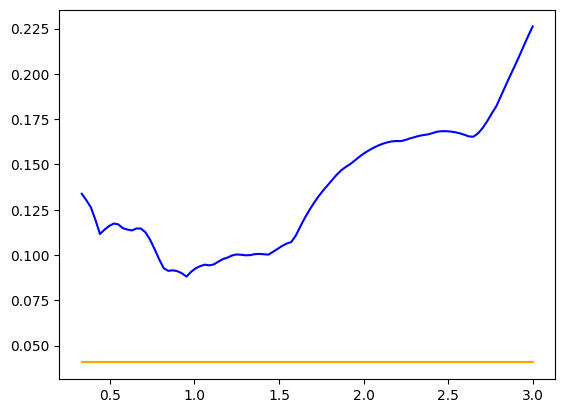

In [14]:
plt.plot(S1_vals, ht_prices_strike, label='Neural Network', color='blue')
plt.plot(S1_vals, tree_price_strike, label='Heston Tree', color='orange')
plt.show()

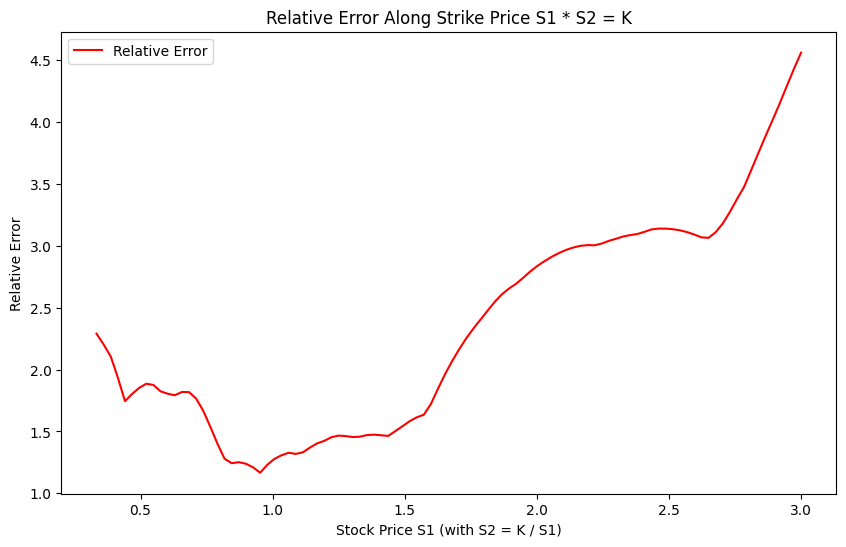

In [15]:
relative_error_strike = np.abs(ht_prices_strike - tree_price_strike) / np.maximum(tree_price_strike, 1e-8)
plt.figure(figsize=(10, 6))
plt.plot(S1_vals, relative_error_strike, label='Relative Error', color='red')
plt.xlabel('Stock Price S1 (with S2 = K / S1)')
plt.ylabel('Relative Error')
plt.title('Relative Error Along Strike Price S1 * S2 = K')
plt.legend()
plt.show()